# Claim Video → Damage Detection Pipeline (Offline)

**Goal:** Take a raw insurance claim video, extract frames intelligently, run the fine-tuned YOLOv8 damage detector on them, and produce a structured, video-level damage report.

**Fully offline:** loads `best_car_damage_yolov8s.pt` from disk — no API calls, no internet dependency. This satisfies the prototype's no-external-API requirement.

**Input:** a claim video file (mp4/mov)
**Output:** a structured damage report (JSON) consumed by the next notebook (audio analysis + risk scoring)

## 1. Setup

In [2]:
!pip install ultralytics

In [3]:
# pip install ultralytics opencv-python moviepy --quiet   # run once if not already installed

import cv2
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path
from collections import defaultdict

MODEL_PATH = '/kaggle/input/notebooks/ronak038/2-icc-yolov8s/car_damage_best.pt'  # <-- adjust if your path differs
CLASS_NAMES = ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']

model = YOLO(MODEL_PATH)
print('Model loaded from:', MODEL_PATH)
print('Classes:', model.names)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Model loaded from: /kaggle/input/notebooks/ronak038/2-icc-yolov8s/car_damage_best.pt
Classes: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}


## 2. Frame Sampling Strategies

Sampling every single frame wastes compute and adds noise from motion blur; sampling too sparsely risks missing the moment damage is actually visible. We'll implement and compare **two strategies**, then pick the better one empirically:

1. **Fixed-interval sampling** — grab 1 frame every N frames (simple, predictable).
2. **Scene-change / motion-based sampling** — grab frames where the visual content changes significantly (better at catching moments the camera pans to reveal damage, skips redundant near-identical frames).

In [4]:
def extract_frames_fixed_interval(video_path, every_n_frames=15):
    """Grab one frame every `every_n_frames` frames."""
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_idx = 0
    fps = cap.get(cv2.CAP_PROP_FPS) or 30

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % every_n_frames == 0:
            timestamp_sec = frame_idx / fps
            frames.append({'frame': frame, 'frame_idx': frame_idx, 'timestamp_sec': round(timestamp_sec, 2)})
        frame_idx += 1

    cap.release()
    return frames


def extract_frames_scene_change(video_path, diff_threshold=25.0, min_gap_frames=5):
    """Grab frames where visual content changes meaningfully vs. the last captured frame.
    Uses mean absolute pixel difference on grayscale downsized frames — cheap and effective.
    """
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_idx = 0
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    prev_gray_small = None
    last_captured_idx = -min_gap_frames

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        small = cv2.resize(frame, (160, 90))
        gray_small = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

        should_capture = False
        if prev_gray_small is None:
            should_capture = True  # always take the first frame
        else:
            diff = np.mean(cv2.absdiff(gray_small, prev_gray_small))
            if diff > diff_threshold and (frame_idx - last_captured_idx) >= min_gap_frames:
                should_capture = True

        if should_capture:
            timestamp_sec = frame_idx / fps
            frames.append({'frame': frame, 'frame_idx': frame_idx, 'timestamp_sec': round(timestamp_sec, 2)})
            prev_gray_small = gray_small
            last_captured_idx = frame_idx

        frame_idx += 1

    cap.release()
    return frames

In [5]:
SAMPLE_VIDEO_PATH = '/kaggle/input/datasets/ronak038/sample-videos-with-audios/claim_edge_long_walkaround.mp4'  # <-- point this at one of your test videos

fixed_frames = extract_frames_fixed_interval(SAMPLE_VIDEO_PATH, every_n_frames=15)
scene_frames = extract_frames_scene_change(SAMPLE_VIDEO_PATH, diff_threshold=25.0)

print(f'Fixed-interval sampling: {len(fixed_frames)} frames extracted')
print(f'Scene-change sampling:   {len(scene_frames)} frames extracted')

Fixed-interval sampling: 21 frames extracted
Scene-change sampling:   28 frames extracted


**Decision point:** run detection with both frame sets (Section 4) and compare which produces more confident, less redundant detections. Document which strategy you keep and why — e.g., "scene-change sampling reduced frame count by 40% while catching the same damage instances, so it's more compute-efficient without losing recall."

## 3. Run Detection on Sampled Frames

In [6]:
def run_detection_on_frames(frames, model, conf_threshold=0.20):
    """Run YOLO on each sampled frame. Returns per-frame detection results.
    conf_threshold=0.20 chosen from the threshold-tuning step in the fine-tuning notebook
    (prioritizing recall — better to flag borderline damage for human review than miss it).
    """
    per_frame_results = []

    for f in frames:
        result = model.predict(f['frame'], conf=conf_threshold, verbose=False)[0]

        detections = []
        for box in result.boxes:
            cls_id = int(box.cls.item())
            detections.append({
                'class': CLASS_NAMES[cls_id],
                'confidence': round(float(box.conf.item()), 3),
                'bbox_xyxy': [round(x, 1) for x in box.xyxy[0].tolist()]
            })

        per_frame_results.append({
            'frame_idx': f['frame_idx'],
            'timestamp_sec': f['timestamp_sec'],
            'detections': detections,
            'annotated_frame': result.plot()  # for visualization only, not saved to JSON
        })

    return per_frame_results


fixed_detections = run_detection_on_frames(fixed_frames, model)
scene_detections = run_detection_on_frames(scene_frames, model)

fixed_total_detections = sum(len(f['detections']) for f in fixed_detections)
scene_total_detections = sum(len(f['detections']) for f in scene_detections)

print(f'Fixed-interval: {len(fixed_frames)} frames → {fixed_total_detections} total detections')
print(f'Scene-change:   {len(scene_frames)} frames → {scene_total_detections} total detections')

Fixed-interval: 21 frames → 78 total detections
Scene-change:   28 frames → 98 total detections


## 4. Visualize Detections

Eyeball a few annotated frames from your chosen strategy — useful for both debugging and demo screenshots.

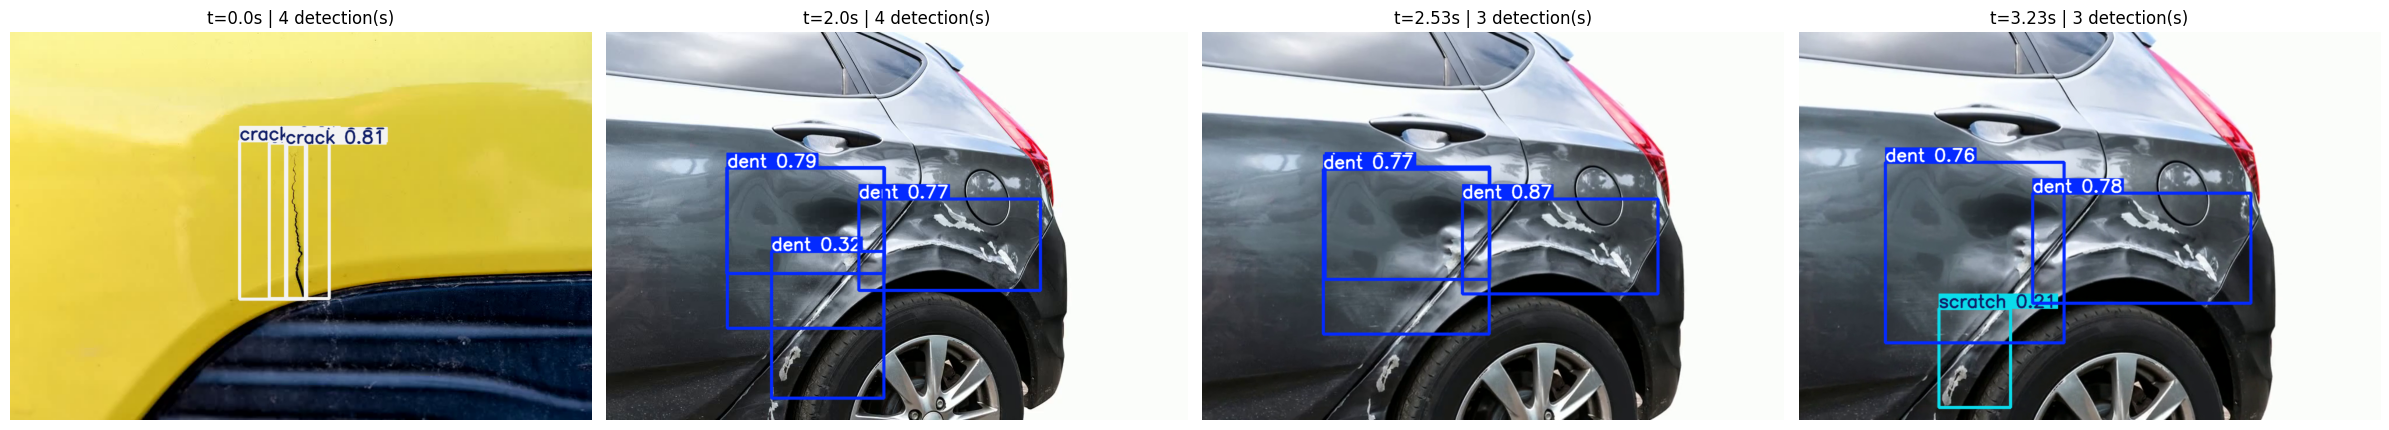

In [7]:
CHOSEN_DETECTIONS = scene_detections  # switch to fixed_detections if that strategy wins

frames_with_damage = [f for f in CHOSEN_DETECTIONS if len(f['detections']) > 0]

n_show = min(4, len(frames_with_damage))
if n_show == 0:
    print('No damage detected in any sampled frame — try lowering conf_threshold or check the video.')
else:
    fig, axes = plt.subplots(1, n_show, figsize=(6 * n_show, 6))
    if n_show == 1:
        axes = [axes]
    for ax, f in zip(axes, frames_with_damage[:n_show]):
        ax.imshow(cv2.cvtColor(f['annotated_frame'], cv2.COLOR_BGR2RGB))
        ax.set_title(f"t={f['timestamp_sec']}s | {len(f['detections'])} detection(s)")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 5. Aggregate Frame-Level Detections → Video-Level Damage Report

A single frame's detection isn't the claim-level answer — we need to combine signal across the whole video:
- Which damage types appear, and how consistently (present in many frames = more trustworthy than a single flicker).
- Peak confidence per damage type (the clearest view of that damage).
- Where in the video (timestamp) each damage type is best seen — useful for a human reviewer to jump straight to the relevant clip.

In [8]:
def aggregate_video_damage_report(per_frame_results, total_sampled_frames):
    """Combine per-frame detections into a claim-level summary."""
    class_stats = defaultdict(lambda: {
        'frame_count': 0,
        'max_confidence': 0.0,
        'best_timestamp_sec': None,
        'confidences': []
    })

    for frame_result in per_frame_results:
        seen_classes_this_frame = set()
        for det in frame_result['detections']:
            cls = det['class']
            conf = det['confidence']
            stats = class_stats[cls]
            stats['confidences'].append(conf)
            if cls not in seen_classes_this_frame:
                stats['frame_count'] += 1
                seen_classes_this_frame.add(cls)
            if conf > stats['max_confidence']:
                stats['max_confidence'] = conf
                stats['best_timestamp_sec'] = frame_result['timestamp_sec']

    damage_summary = []
    for cls, stats in class_stats.items():
        damage_summary.append({
            'damage_type': cls,
            'frames_detected_in': stats['frame_count'],
            'frame_consistency_pct': round(100 * stats['frame_count'] / total_sampled_frames, 1),
            'max_confidence': round(stats['max_confidence'], 3),
            'avg_confidence': round(float(np.mean(stats['confidences'])), 3),
            'best_timestamp_sec': stats['best_timestamp_sec']
        })

    # Sort by max confidence, most severe/certain damage first
    damage_summary.sort(key=lambda x: x['max_confidence'], reverse=True)

    return {
        'total_sampled_frames': total_sampled_frames,
        'frames_with_any_damage': sum(1 for f in per_frame_results if len(f['detections']) > 0),
        'damage_types_found': [d['damage_type'] for d in damage_summary],
        'damage_summary': damage_summary
    }


video_report = aggregate_video_damage_report(CHOSEN_DETECTIONS, len(CHOSEN_DETECTIONS))
print(json.dumps(video_report, indent=2))

{
  "total_sampled_frames": 28,
  "frames_with_any_damage": 27,
  "damage_types_found": [
    "lamp broken",
    "tire flat",
    "scratch",
    "dent",
    "crack"
  ],
  "damage_summary": [
    {
      "damage_type": "lamp broken",
      "frames_detected_in": 15,
      "frame_consistency_pct": 53.6,
      "max_confidence": 0.966,
      "avg_confidence": 0.943,
      "best_timestamp_sec": 5.93
    },
    {
      "damage_type": "tire flat",
      "frames_detected_in": 1,
      "frame_consistency_pct": 3.6,
      "max_confidence": 0.933,
      "avg_confidence": 0.933,
      "best_timestamp_sec": 10.0
    },
    {
      "damage_type": "scratch",
      "frames_detected_in": 19,
      "frame_consistency_pct": 67.9,
      "max_confidence": 0.931,
      "avg_confidence": 0.711,
      "best_timestamp_sec": 6.1
    },
    {
      "damage_type": "dent",
      "frames_detected_in": 20,
      "frame_consistency_pct": 71.4,
      "max_confidence": 0.93,
      "avg_confidence": 0.689,
      "best_t

## 6. A Simple Visual Damage Score (0-100)

For the risk-scoring notebook, we need a single number summarizing visual damage severity. This is a **transparent, documented heuristic** — not a black box — which matters for demo credibility.

Logic:
- More distinct damage types → higher severity.
- Higher confidence → higher severity.
- More consistent presence across frames → higher severity (reduces false-positive risk from a single flickering detection).

Weights below are a documented starting point for the prototype — call this out explicitly as tunable/future-work (e.g., could be learned from adjuster-labeled claim outcomes in Phase 2).

In [9]:
# Optional: rank damage types by rough severity for weighting (documented assumption)
SEVERITY_WEIGHTS = {
    'crack': 1.0,
    'glass shatter': 1.0,
    'dent': 0.7,
    'lamp broken': 0.7,
    'tire flat': 0.9,
    'scratch': 0.4
}

def compute_visual_damage_score(damage_summary):
    if not damage_summary:
        return 0.0

    per_type_scores = []
    for d in damage_summary:
        weight = SEVERITY_WEIGHTS.get(d['damage_type'], 0.5)
        consistency_factor = d['frame_consistency_pct'] / 100
        type_score = weight * d['max_confidence'] * (0.5 + 0.5 * consistency_factor)
        per_type_scores.append(type_score)

    # Combine: take the max (worst single damage) plus a smaller contribution from
    # additional damage types, capped at 100
    per_type_scores.sort(reverse=True)
    combined = per_type_scores[0] + 0.3 * sum(per_type_scores[1:])
    score_0_100 = min(round(combined * 100, 1), 100.0)
    return score_0_100


visual_damage_score = compute_visual_damage_score(video_report['damage_summary'])
video_report['visual_damage_score'] = visual_damage_score
print(f"Visual Damage Score: {visual_damage_score} / 100")

Visual Damage Score: 100.0 / 100


## 7. Save Structured Report for Downstream Notebooks

In [10]:
os.makedirs('reports', exist_ok=True)
video_name = Path(SAMPLE_VIDEO_PATH).stem
output_path = f'reports/{video_name}_visual_report.json'

with open(output_path, 'w') as f:
    json.dump(video_report, f, indent=2)

print(f'Saved visual damage report to: {output_path}')

Saved visual damage report to: reports/claim_edge_long_walkaround_visual_report.json


## 8. Batch-Process Multiple Test Videos (for your evaluation notebook)

Run this against your full sample set (e.g., 5-10 videos: clean claims, ambiguous, staged/fraud-like) so Notebook 4 (evaluation) has real data to validate against.

In [12]:
def process_video_end_to_end(video_path, model, sampling='scene_change', conf_threshold=0.20):
    if sampling == 'scene_change':
        frames = extract_frames_scene_change(video_path)
    else:
        frames = extract_frames_fixed_interval(video_path)

    detections = run_detection_on_frames(frames, model, conf_threshold=conf_threshold)
    report = aggregate_video_damage_report(detections, len(detections))
    report['visual_damage_score'] = compute_visual_damage_score(report['damage_summary'])
    report['video_path'] = video_path
    return report


SAMPLE_VIDEOS_DIR = '/kaggle/input/datasets/ronak038/sample-videos-with-audios'
all_reports = {}

for video_file in os.listdir(SAMPLE_VIDEOS_DIR):
    if video_file.lower().endswith(('.mp4', '.mov', '.avi')):
        path = os.path.join(SAMPLE_VIDEOS_DIR, video_file)
        print(f'Processing {video_file}...')
        all_reports[video_file] = process_video_end_to_end(path, model)

with open('reports/all_videos_visual_reports.json', 'w') as f:
    json.dump(all_reports, f, indent=2)

print(f'\nProcessed {len(all_reports)} videos. Combined report saved to reports/all_videos_visual_reports.json')

for name, r in all_reports.items():
    print(f"  {name}: score={r['visual_damage_score']}, types={r['damage_types_found']}")

Processing claim_mixed_4.mp4...
Processing claim_single_scratch_v1.mp4...
Processing claim_single_tire_flat_v1.mp4...
Processing claim_mixed_1.mp4...
Processing claim_pair_crack_glass_shatter.mp4...
Processing claim_pair_scratch_crack.mp4...
Processing claim_single_tire_flat_v2.mp4...
Processing claim_single_crack_v2.mp4...
Processing claim_mixed_2.mp4...
Processing claim_single_lamp_broken_v2.mp4...
Processing claim_pair_lamp_broken_scratch.mp4...
Processing claim_mixed_6.mp4...
Processing claim_single_dent_v2.mp4...
Processing claim_pair_dent_crack.mp4...
Processing claim_single_crack_v1.mp4...
Processing claim_single_scratch_v2.mp4...
Processing claim_mixed_5.mp4...
Processing claim_edge_long_walkaround.mp4...
Processing claim_pair_dent_scratch.mp4...
Processing claim_single_dent_v1.mp4...
Processing claim_edge_single_image.mp4...
Processing claim_mixed_3.mp4...
Processing claim_single_glass_shatter_v2.mp4...
Processing claim_single_lamp_broken_v1.mp4...
Processing claim_single_glas

## Next Notebook

`03_audio_analysis.ipynb` will:
1. Extract the audio track from each claim video.
2. Run local Whisper transcription (optional) + librosa acoustic feature extraction (pitch variance, pace, pauses).
3. Produce a per-video audio consistency/stress score.

Both notebooks' outputs (`visual_damage_score` + audio score) feed into `04_risk_scoring_and_summary.ipynb`, where they're combined into the final Claim Risk Score.